# Marketing Funnel Analysis

This notebook focuses on analyzing the marketing funnel using the cleaned
bank marketing dataset.

The objective is to:
- Measure overall conversion performance
- Identify major drop-off points
- Understand how campaign-related variables affect conversions

This directly addresses Task-3: Marketing Funnel & Conversion Performance Analysis.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_palette("muted")

In [2]:
# Load cleaned dataset
df = pd.read_csv("bank_marketing_cleaned.csv")

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no,0


### Funnel Definition

In this dataset, the marketing funnel can be simplified as:

Contacted Customer → Subscribed to Term Deposit

Since every row represents a contacted customer, the main funnel drop-off
occurs at the subscription stage.

In [3]:
# Overall conversion metrics
total_contacts = len(df)
total_conversions = df["y_binary"].sum()
conversion_rate = (total_conversions / total_contacts) * 100

total_contacts, total_conversions, round(conversion_rate, 2)

(45211, np.int64(5289), np.float64(11.7))

The overall conversion rate represents the percentage of contacted customers
who subscribed to a term deposit.

In real-world outbound marketing campaigns, conversion rates are typically low,
making even small improvements highly valuable.

In [4]:
funnel_df = pd.DataFrame({
    "Stage": ["Contacted", "Converted"],
    "Customers": [total_contacts, total_conversions]
})

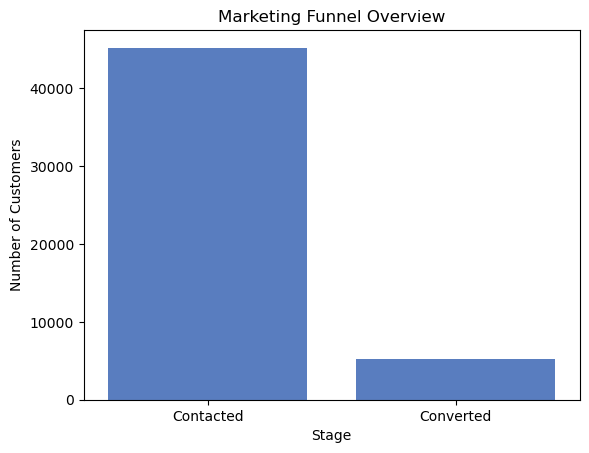

In [ ]:
sns.barplot(data = funnel_df, x="Stage", y="Customers")
plt.title("Marketing Funnel Overview")
plt.ylabel("Number of Customers")
plt.show()

In [6]:
contact_conv = (
    df.groupby("contact")["y_binary"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

contact_conv

contact
cellular     14.918900
telephone    13.420509
Name: y_binary, dtype: float64

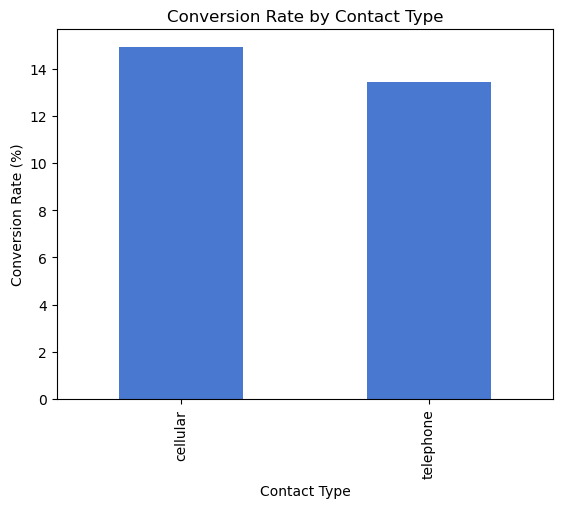

In [7]:
contact_conv.plot(kind="bar")
plt.title("Conversion Rate by Contact Type")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Contact Type")
plt.show()

Different contact methods result in significantly different conversion rates.

This suggests that channel selection plays a critical role in campaign success
and should be optimized to reduce funnel drop-offs.

In [8]:
campaign_conv = (
    df.groupby("campaign")["y_binary"]
    .mean()
    * 100
)

campaign_conv.head(10)

campaign
1     14.597583
2     11.203519
3     11.193624
4      9.000568
5      7.879819
6      7.126259
7      6.394558
8      5.925926
9      6.422018
10     5.263158
Name: y_binary, dtype: float64

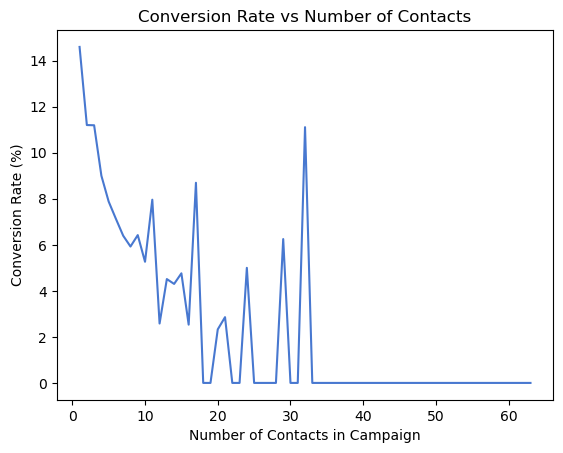

In [9]:
sns.lineplot(x = campaign_conv.index, y = campaign_conv.values)
plt.title("Conversion Rate vs Number of Contacts")
plt.xlabel("Number of Contacts in Campaign")
plt.ylabel("Conversion Rate (%)")
plt.show()

Conversion rates tend to decrease as the number of contact attempts increases.

This indicates diminishing returns and possible customer fatigue,
which is a major contributor to funnel drop-off.